# Data Preprocessing EDA (Face Crops)
This notebook explains why cropped images are fixed size and performs EDA with Seaborn on original and cropped datasets.

## 1. Load Libraries and Configure Paths

In [1]:

import os
from glob import glob
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

target_rel = Path("2_Train_FaceRecognition_with_ML") / "data" / "Dataset.csv"
WORKSPACE = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / target_rel).exists():
        WORKSPACE = p
        break

if WORKSPACE is None:
    raise FileNotFoundError(f"Could not find {target_rel} from {Path.cwd()}")

BASE = WORKSPACE / "2_Train_FaceRecognition_with_ML" / "data"
CSV_PATH = BASE / "Dataset.csv"
SRC_ROOT = BASE / "Original Images" / "Original Images"
CROP_ROOT = BASE / "Faces" / "Faces"
FAIL_LOG = BASE / "crop_failures.csv"
EDA_OUT = BASE / "eda_outputs"
EDA_OUT.mkdir(parents=True, exist_ok=True)

print("Workspace:", WORKSPACE)
print("CSV:", CSV_PATH)
print("Source dir exists:", SRC_ROOT.exists())
print("Crop dir exists:", CROP_ROOT.exists())
print("Failure log exists:", FAIL_LOG.exists())
print("EDA output dir:", EDA_OUT)

Workspace: c:\Users\schha\attendify_scratch
CSV: c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\Dataset.csv
Source dir exists: True
Crop dir exists: True
Failure log exists: True
EDA output dir: c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\eda_outputs


## 2. Load Dataset Metadata and Basic Integrity Checks

In [2]:
df = pd.read_csv(CSV_PATH)
required_cols = {"id", "label"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.copy()
df["src_path"] = df.apply(lambda r: SRC_ROOT / r["label"] / r["id"], axis=1)
df["crop_path"] = df["id"].apply(lambda x: CROP_ROOT / x)
df["src_exists"] = df["src_path"].apply(Path.exists)
df["crop_exists"] = df["crop_path"].apply(Path.exists)

print("Total rows:", len(df))
print("Unique labels:", df["label"].nunique())
print("Duplicate id rows:", int(df.duplicated(subset=["id"]).sum()))
print("Duplicate (id,label) rows:", int(df.duplicated(subset=["id", "label"]).sum()))
print("Nulls by column:")
display(df[["id", "label"]].isnull().sum().to_frame("null_count"))

integrity = pd.Series({
    "total_rows": len(df),
    "source_exists": int(df["src_exists"].sum()),
    "source_missing": int((~df["src_exists"]).sum()),
    "crop_exists": int(df["crop_exists"].sum()),
    "crop_missing": int((~df["crop_exists"]).sum()),
})
display(integrity.to_frame("value"))

Total rows: 2562
Unique labels: 31
Duplicate id rows: 0
Duplicate (id,label) rows: 0
Nulls by column:


,null_count
id,0
label,0


,value
total_rows,2562
source_exists,2562
source_missing,0
crop_exists,2475
crop_missing,87


## 3. Audit Current Cropping Logic (Why All Crops Are Same Size)

In [3]:
OUT_SIZE = (160, 160)
print("Configured fixed output size in preprocessing:", OUT_SIZE)

existing_crop_paths = df.loc[df["crop_exists"], "crop_path"].tolist()
sample_paths = existing_crop_paths[: min(300, len(existing_crop_paths))]

crop_shapes = []
for p in sample_paths:
    img = cv2.imread(str(p))
    if img is not None:
        h, w = img.shape[:2]
        crop_shapes.append((w, h))

shape_df = pd.DataFrame(crop_shapes, columns=["width", "height"])
if len(shape_df) == 0:
    print("No cropped images found to audit.")
else:
    unique_shapes = shape_df.value_counts().reset_index(name="count")
    print("Unique cropped sizes in sample:", len(unique_shapes))
    display(unique_shapes.head(10))
    print("All sampled crops equal OUT_SIZE:", bool(((shape_df["width"] == OUT_SIZE[0]) & (shape_df["height"] == OUT_SIZE[1])).all()))

Configured fixed output size in preprocessing: (160, 160)
Unique cropped sizes in sample: 1


,width,height,count
0,160,160,300


All sampled crops equal OUT_SIZE: True


## 4. Compute Image Dimension Statistics (Original vs Cropped)

In [4]:
# Set MAX_FILES=None to scan all rows, or an integer for faster EDA
MAX_FILES = None
work_df = df.copy() if MAX_FILES is None else df.head(MAX_FILES).copy()

stats_rows = []
for _, r in tqdm(work_df.iterrows(), total=len(work_df)):
    src_p = r["src_path"]
    crop_p = r["crop_path"]

    if src_p.exists():
        img = cv2.imread(str(src_p))
        if img is not None:
            h, w = img.shape[:2]
            stats_rows.append({
                "id": r["id"],
                "label": r["label"],
                "split_type": "original",
                "width": w,
                "height": h,
                "aspect_ratio": w / h if h else np.nan,
                "pixel_count": w * h,
            })

    if crop_p.exists():
        img = cv2.imread(str(crop_p))
        if img is not None:
            h, w = img.shape[:2]
            stats_rows.append({
                "id": r["id"],
                "label": r["label"],
                "split_type": "cropped",
                "width": w,
                "height": h,
                "aspect_ratio": w / h if h else np.nan,
                "pixel_count": w * h,
            })

dim_df = pd.DataFrame(stats_rows)
print("Dimension rows:", len(dim_df))
display(dim_df.head())

summary_dim = dim_df.groupby("split_type")[["width", "height", "aspect_ratio", "pixel_count"]].describe()
display(summary_dim)

100%|██████████| 2562/2562 [01:34<00:00, 27.14it/s]

Dimension rows: 5037


,id,label,split_type,width,height,aspect_ratio,pixel_count
0,Robert Downey Jr_87.jpg,Robert Downey Jr,original,640,320,2.000000,204800
1,Robert Downey Jr_87.jpg,Robert Downey Jr,cropped,160,160,1.000000,25600
2,Lisa Kudrow_64.jpg,Lisa Kudrow,original,1484,1485,0.999327,2203740
3,Lisa Kudrow_64.jpg,Lisa Kudrow,cropped,160,160,1.000000,25600
4,Ellen Degeneres_34.jpg,Ellen Degeneres,original,612,612,1.000000,374544


width                                                        \
             count         mean         std    min    25%    50%     75%   
split_type                                                                 
cropped     2475.0   160.000000    0.000000  160.0  160.0  160.0   160.0   
original    2562.0  1099.379781  672.256235  216.0  662.5  967.0  1280.0   

                    height               ... aspect_ratio            \
               max   count         mean  ...          75%       max   
split_type                               ...                          
cropped      160.0  2475.0   160.000000  ...     1.000000  1.000000   
original    5760.0  2562.0  1125.444965  ...     1.500586  2.660578   

           pixel_count                                                 \
                 count          mean           std      min       25%   
split_type                                                              
cropped         2475.0  2.560000e+04  0.000000e+00  25600.0   25600.0   
original        2562.0  1.655322e+06  2.565887e+06  48396.0  415834.0   

                                             
                 50%        75%         max  
split_type                                   
cropped      25600.0    25600.0     25600.0  
original    770175.0  1968900.0  22118400.0  

[2 rows x 32 columns]

## 5. Visualize Size Distributions with Seaborn

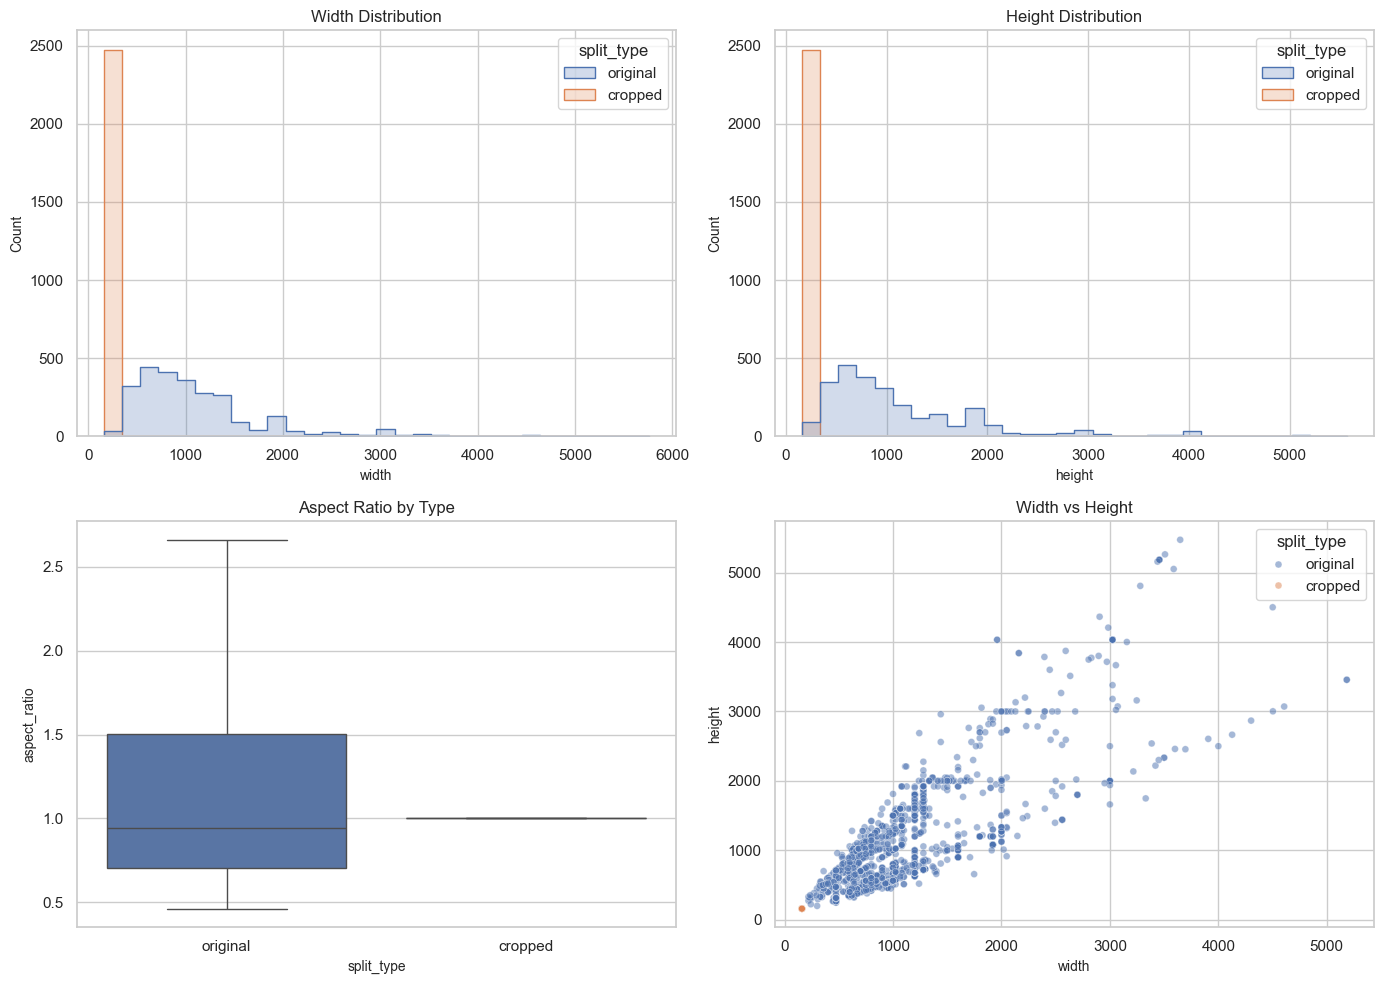

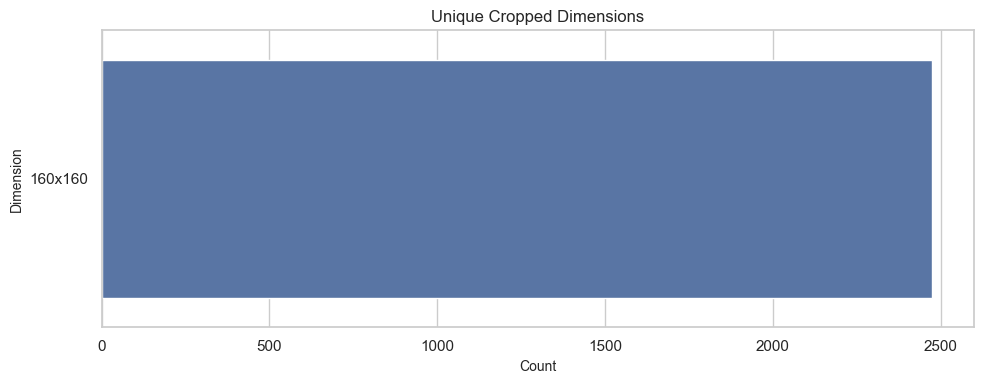

In [5]:
if len(dim_df) == 0:
    print("No dimension data to plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.histplot(data=dim_df, x="width", hue="split_type", bins=30, element="step", stat="count", common_norm=False, ax=axes[0, 0])
    axes[0, 0].set_title("Width Distribution")

    sns.histplot(data=dim_df, x="height", hue="split_type", bins=30, element="step", stat="count", common_norm=False, ax=axes[0, 1])
    axes[0, 1].set_title("Height Distribution")

    sns.boxplot(data=dim_df, x="split_type", y="aspect_ratio", ax=axes[1, 0])
    axes[1, 0].set_title("Aspect Ratio by Type")

    sampled = dim_df.sample(min(3000, len(dim_df)), random_state=42)
    sns.scatterplot(data=sampled, x="width", y="height", hue="split_type", alpha=0.5, s=25, ax=axes[1, 1])
    axes[1, 1].set_title("Width vs Height")

    plt.tight_layout()
    plt.show()

    crop_only = dim_df[dim_df["split_type"] == "cropped"].copy()
    if len(crop_only):
        crop_only["size_str"] = crop_only["width"].astype(str) + "x" + crop_only["height"].astype(str)
        plt.figure(figsize=(10, 4))
        sns.countplot(data=crop_only, y="size_str", order=crop_only["size_str"].value_counts().index)
        plt.title("Unique Cropped Dimensions")
        plt.xlabel("Count")
        plt.ylabel("Dimension")
        plt.tight_layout()
        plt.show()

## 6. Analyze Label Distribution and Class Imbalance

,label,count
0,Brad Pitt,120
1,Vijay Deverakonda,115
2,Robert Downey Jr,113
3,Hugh Jackman,112
4,Jessica Alba,108


Class count stats
Min: 30
Median: 80.0
Q1: 70.5
Q3: 101.5
Max: 120


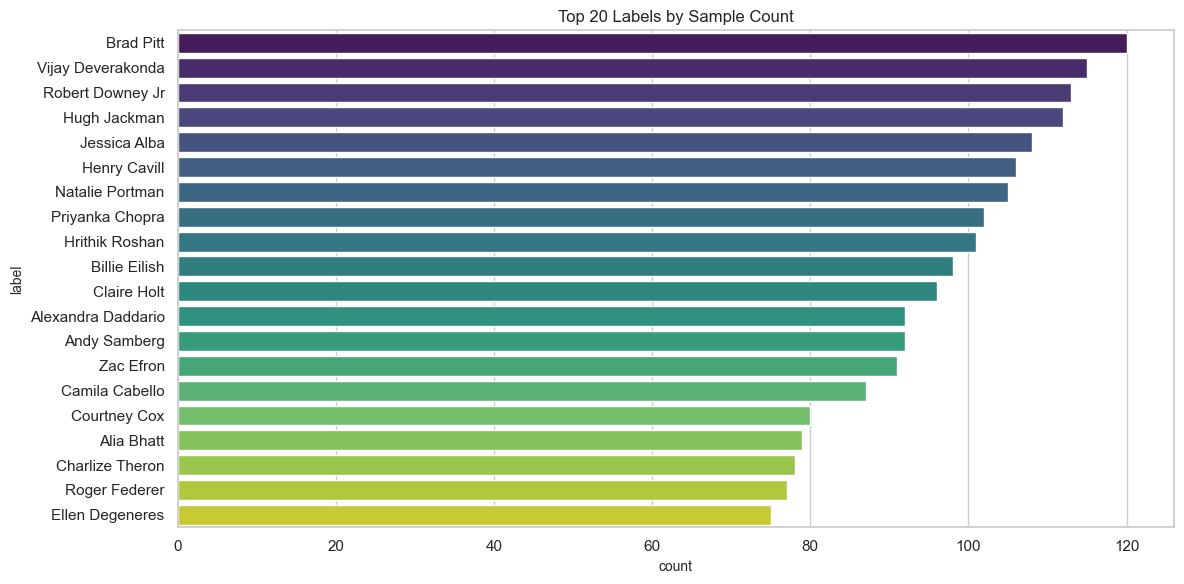

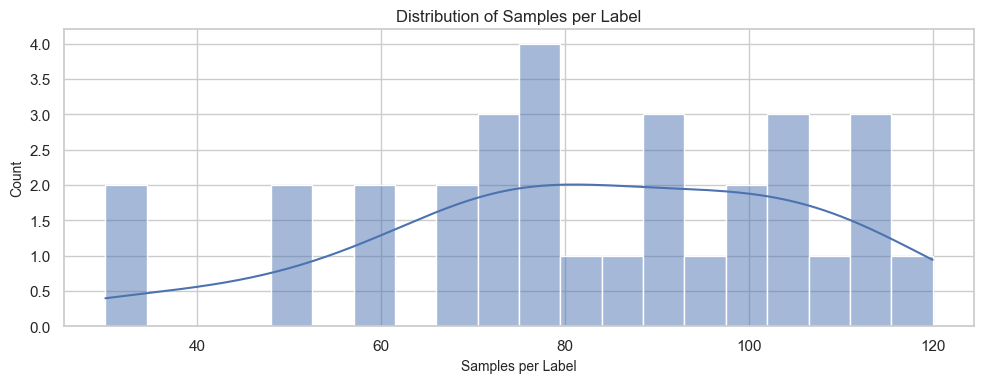

Classes with <= 50 samples: 4


,label,count
27,Akshay Kumar,50
28,Virat Kohli,49
29,Marmik,32
30,Kashyap,30


In [10]:
label_counts = df["label"].value_counts().rename_axis("label").reset_index(name="count")
display(label_counts.head())

print("Class count stats")
print("Min:", int(label_counts["count"].min()))
print("Median:", float(label_counts["count"].median()))
print("Q1:", float(label_counts["count"].quantile(0.25)))
print("Q3:", float(label_counts["count"].quantile(0.75)))
print("Max:", int(label_counts["count"].max()))

top_k = min(20, len(label_counts))
plt.figure(figsize=(12, 6))
sns.barplot(data=label_counts.head(top_k), x="count", y="label", hue="label", palette="viridis", dodge=False, legend=False)
plt.title(f"Top {top_k} Labels by Sample Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(label_counts["count"], bins=20, kde=True)
plt.title("Distribution of Samples per Label")
plt.xlabel("Samples per Label")
plt.tight_layout()
plt.show()

low_threshold = max(5, int(label_counts["count"].quantile(0.1)))
low_classes = label_counts[label_counts["count"] <= low_threshold]
print(f"Classes with <= {low_threshold} samples: {len(low_classes)}")
display(low_classes.head(20))

## 7. Failure Log EDA (Missing Files, No Face, Bad Crop)

Total failed records: 87


,id,label,reason
0,Billie Eilish_3.jpg,Billie Eilish,no_face_detected
1,Hrithik Roshan_35.jpg,Hrithik Roshan,no_face_detected
2,Claire Holt_28.jpg,Claire Holt,no_face_detected
3,Hrithik Roshan_84.jpg,Hrithik Roshan,no_face_detected
4,Hrithik Roshan_100.jpg,Hrithik Roshan,no_face_detected


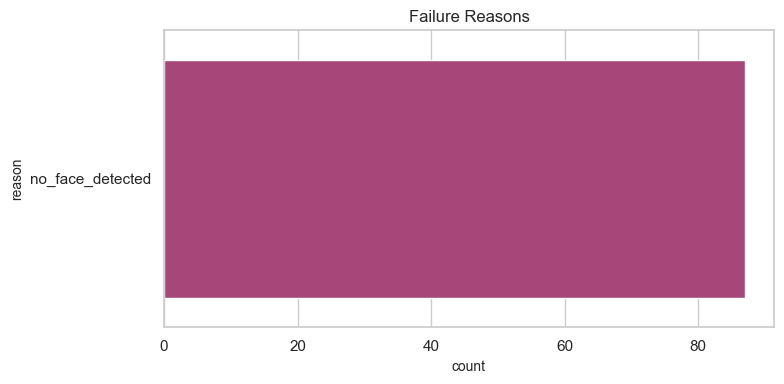

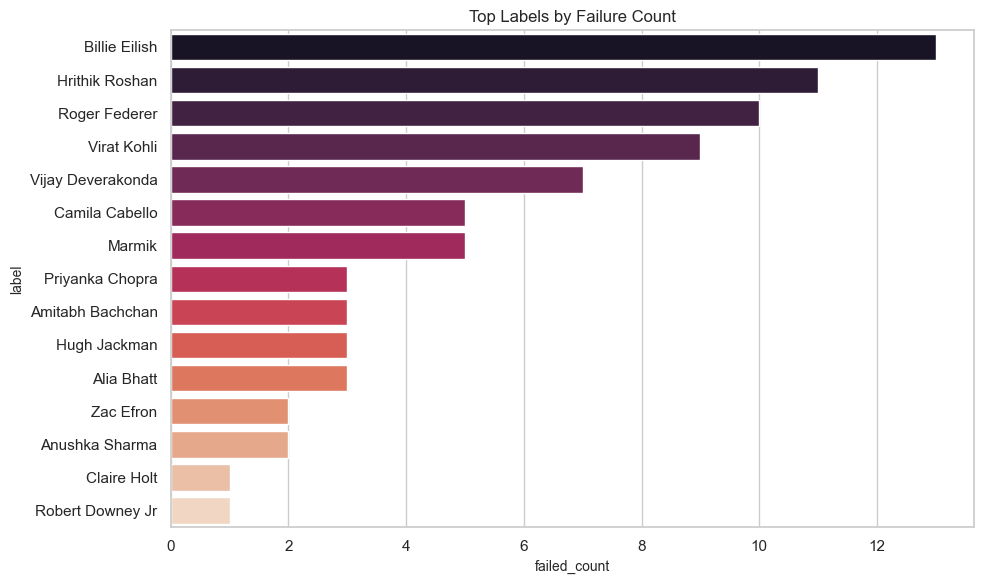

,total_count,failed_count,failure_rate
label,,,
Virat Kohli,49,9,0.183673
Marmik,32,5,0.156250
Billie Eilish,98,13,0.132653
Roger Federer,77,10,0.129870
Hrithik Roshan,101,11,0.108911
Vijay Deverakonda,115,7,0.060870
Camila Cabello,87,5,0.057471
Amitabh Bachchan,74,3,0.040541
Alia Bhatt,79,3,0.037975


Overall failure rate: 0.0340


In [11]:
if FAIL_LOG.exists():
    fail_df = pd.read_csv(FAIL_LOG)
    print("Total failed records:", len(fail_df))
    display(fail_df.head())

    plt.figure(figsize=(8, 4))
    sns.countplot(data=fail_df, y="reason", hue="reason", order=fail_df["reason"].value_counts().index, palette="magma", legend=False)
    plt.title("Failure Reasons")
    plt.tight_layout()
    plt.show()

    top_fail_labels = fail_df["label"].value_counts().head(15).rename_axis("label").reset_index(name="failed_count")
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_fail_labels, x="failed_count", y="label", hue="label", palette="rocket", dodge=False, legend=False)
    plt.title("Top Labels by Failure Count")
    plt.tight_layout()
    plt.show()

    total_by_label = df["label"].value_counts().rename("total_count")
    failed_by_label = fail_df["label"].value_counts().rename("failed_count")
    fail_rate_df = pd.concat([total_by_label, failed_by_label], axis=1).fillna(0)
    fail_rate_df["failed_count"] = fail_rate_df["failed_count"].astype(int)
    fail_rate_df["failure_rate"] = fail_rate_df["failed_count"] / fail_rate_df["total_count"]
    fail_rate_df = fail_rate_df.sort_values("failure_rate", ascending=False)
    display(fail_rate_df.head(20))

    overall_failure_rate = len(fail_df) / len(df) if len(df) else np.nan
    print(f"Overall failure rate: {overall_failure_rate:.4f}")
else:
    fail_df = pd.DataFrame(columns=["id", "label", "reason"])
    fail_rate_df = pd.DataFrame()
    print("Failure log not found. Skipping failure EDA.")

## 8. Sample Visual Inspection Grid (Original vs Cropped)

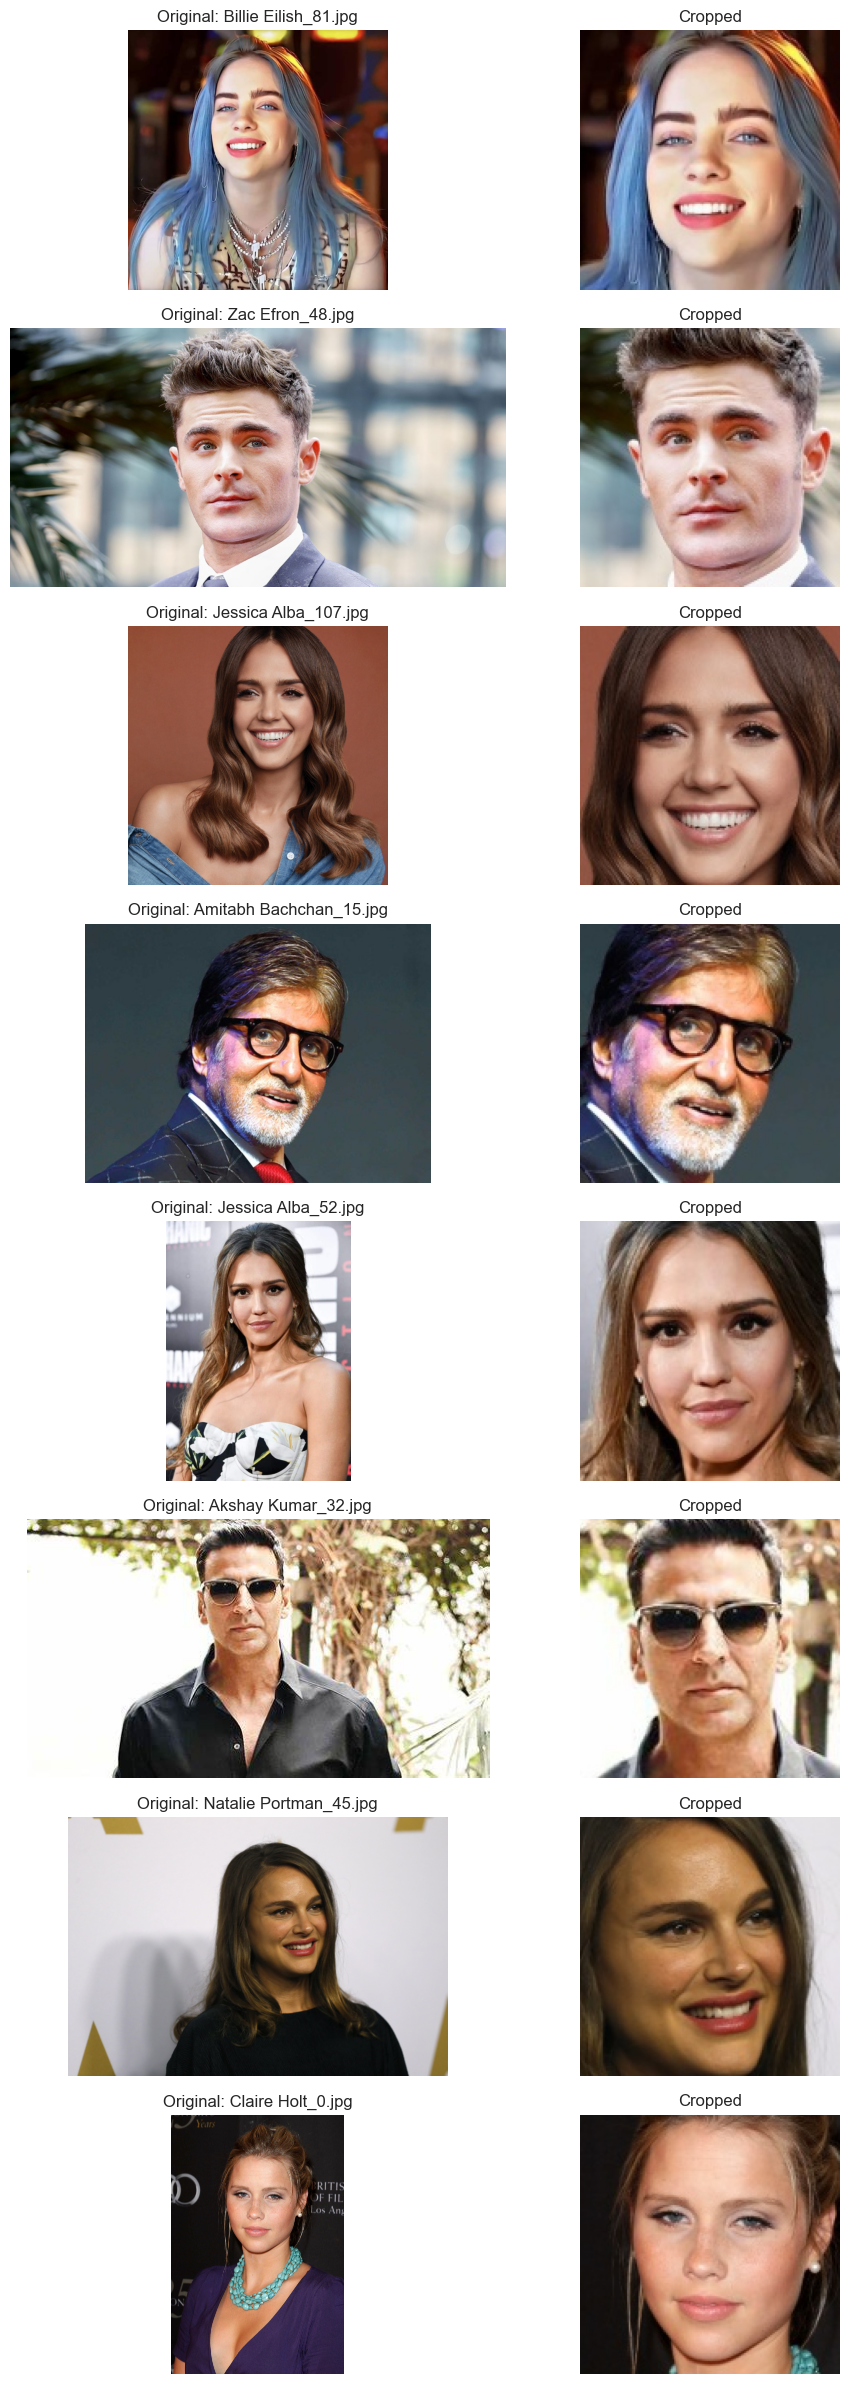

In [8]:
pair_candidates = df[df["src_exists"] & df["crop_exists"]].copy()
n_pairs = min(8, len(pair_candidates))

if n_pairs == 0:
    print("No source-crop pairs available for visual inspection.")
else:
    sample_pairs = pair_candidates.sample(n_pairs, random_state=42)
    fig, axes = plt.subplots(n_pairs, 2, figsize=(10, 3 * n_pairs))
    if n_pairs == 1:
        axes = np.array([axes])

    for i, (_, row) in enumerate(sample_pairs.iterrows()):
        src_img = cv2.imread(str(row["src_path"]))
        crop_img = cv2.imread(str(row["crop_path"]))

        if src_img is not None:
            src_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB)
            axes[i, 0].imshow(src_img)
        axes[i, 0].set_title(f"Original: {row['id']}")
        axes[i, 0].axis("off")

        if crop_img is not None:
            crop_img = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
            axes[i, 1].imshow(crop_img)
        axes[i, 1].set_title("Cropped")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

## 9. Export EDA Summary Tables and Plots

In [12]:
# Save summary tables
size_stats_path = EDA_OUT / "size_stats.csv"
label_dist_path = EDA_OUT / "label_distribution.csv"
failure_summary_path = EDA_OUT / "failure_summary.csv"

summary_dim.reset_index().to_csv(size_stats_path, index=False)
label_counts.to_csv(label_dist_path, index=False)

if len(fail_rate_df):
    fail_rate_df.reset_index(names="label").to_csv(failure_summary_path, index=False)
else:
    pd.DataFrame(columns=["label", "total_count", "failed_count", "failure_rate"]).to_csv(failure_summary_path, index=False)

# Save selected plots
plt.figure(figsize=(10, 4))
sns.histplot(data=dim_df, x="width", hue="split_type", bins=30, element="step", stat="count", common_norm=False)
plt.title("Width Distribution (Original vs Cropped)")
plt.tight_layout()
plt.savefig(EDA_OUT / "width_distribution.png", dpi=150)
plt.close()

plt.figure(figsize=(12, 6))
sns.barplot(data=label_counts.head(min(20, len(label_counts))), x="count", y="label", hue="label", palette="viridis", dodge=False, legend=False)
plt.title("Top Labels by Sample Count")
plt.tight_layout()
plt.savefig(EDA_OUT / "top_label_distribution.png", dpi=150)
plt.close()

if FAIL_LOG.exists() and len(fail_df):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=fail_df, y="reason", hue="reason", order=fail_df["reason"].value_counts().index, palette="magma", legend=False)
    plt.title("Failure Reasons")
    plt.tight_layout()
    plt.savefig(EDA_OUT / "failure_reasons.png", dpi=150)
    plt.close()

print("Saved:")
print("-", size_stats_path)
print("-", label_dist_path)
print("-", failure_summary_path)
print("- plot files in", EDA_OUT)

Saved:
- c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\eda_outputs\size_stats.csv
- c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\eda_outputs\label_distribution.csv
- c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\eda_outputs\failure_summary.csv
- plot files in c:\Users\schha\attendify_scratch\2_Train_FaceRecognition_with_ML\data\eda_outputs
